In [1]:
import os
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
DATASET_PATH = "/Users/rishusingh/Downloads/GeoLife_Extracted/Geolife Trajectories 1.3/Data"
print("Dataset path:", DATASET_PATH)
print("Exists:", os.path.exists(DATASET_PATH))

Dataset path: /Users/rishusingh/Downloads/GeoLife_Extracted/Geolife Trajectories 1.3/Data
Exists: True


In [3]:
data_path = DATASET_PATH
print("Data folder:", data_path)
print("Exists:", os.path.exists(data_path))

Data folder: /Users/rishusingh/Downloads/GeoLife_Extracted/Geolife Trajectories 1.3/Data
Exists: True


In [4]:
user_folders = [
    folder for folder in os.listdir(data_path)
    if os.path.isdir(os.path.join(data_path, folder))
]

print("Number of users:", len(user_folders))
print("First 10 users:", user_folders[:10])

Number of users: 182
First 10 users: ['135', '132', '104', '103', '168', '157', '150', '159', '166', '161']


In [5]:
first_user = user_folders[0]
user_path = os.path.join(data_path, first_user)
print("User:", first_user)
print("Files/Folders:")
print(os.listdir(user_path))

User: 135
Files/Folders:
['Trajectory']


In [6]:
trajectory_path = os.path.join(user_path, "Trajectory")
trajectory_files = [
    file for file in os.listdir(trajectory_path)
    if file.endswith(".plt")
]
print("Number of trajectory files:", len(trajectory_files))
print("First 5 files:", trajectory_files[:5])

Number of trajectory files: 13
First 5 files: ['20090103012134.plt', '20090102043127.plt', '20090127030004.plt', '20090110011947.plt', '20081227072604.plt']


In [7]:
sample_file = os.path.join(
    trajectory_path,
    trajectory_files[0]
)

sample_df = pd.read_csv(
    sample_file,
    skiprows=6,
    header=None
)

sample_df.head()

,0,1,2,3,4,5,6
0,39.974294,116.399741,0,492,39816.056644,2009-01-03,01:21:34
1,39.974292,116.399592,0,492,39816.056655,2009-01-03,01:21:35
2,39.974309,116.399523,0,492,39816.056667,2009-01-03,01:21:36
3,39.974320,116.399588,0,492,39816.056690,2009-01-03,01:21:38
4,39.974365,116.399730,0,491,39816.056701,2009-01-03,01:21:39


In [8]:
sample_df.columns = [
    "latitude",
    "longitude",
    "zero",
    "altitude",
    "date_days",
    "date",
    "time"
]

sample_df.head()

,latitude,longitude,zero,altitude,date_days,date,time
0,39.974294,116.399741,0,492,39816.056644,2009-01-03,01:21:34
1,39.974292,116.399592,0,492,39816.056655,2009-01-03,01:21:35
2,39.974309,116.399523,0,492,39816.056667,2009-01-03,01:21:36
3,39.974320,116.399588,0,492,39816.056690,2009-01-03,01:21:38
4,39.974365,116.399730,0,491,39816.056701,2009-01-03,01:21:39


In [9]:
print("Shape:", sample_df.shape)

print("\nColumns:")
print(sample_df.columns.tolist())

print("\nData types:")
print(sample_df.dtypes)

Shape: (2391, 7)

Columns:
['latitude', 'longitude', 'zero', 'altitude', 'date_days', 'date', 'time']

Data types:
latitude     float64
longitude    float64
zero           int64
altitude       int64
date_days    float64
date             str
time             str
dtype: object


In [10]:
all_trajectories = []

In [11]:
for user_id in user_folders:

    user_trajectory_path = os.path.join(
        data_path,
        user_id,
        "Trajectory"
    )

    if not os.path.exists(user_trajectory_path):
        continue

    trajectory_files = [
        file for file in os.listdir(user_trajectory_path)
        if file.endswith(".plt")
    ]

    for file in trajectory_files:

        file_path = os.path.join(
            user_trajectory_path,
            file
        )

        try:
            df = pd.read_csv(
                file_path,
                skiprows=6,
                header=None
            )

            df.columns = [
                "latitude",
                "longitude",
                "zero",
                "altitude",
                "date_days",
                "date",
                "time"
            ]

            df["user_id"] = user_id

            all_trajectories.append(df)

        except Exception as e:
            print("Error reading:", file_path)
            print(e)

In [12]:
gps_data = pd.concat(
    all_trajectories,
    ignore_index=True
)
print("Total records:", len(gps_data))
print("Shape:", gps_data.shape)

Total records: 24876978
Shape: (24876978, 8)


In [13]:
gps_data = gps_data[
    [
        "user_id",
        "latitude",
        "longitude",
        "altitude",
        "date_days",
        "date",
        "time"
    ]
]

gps_data.head()

,user_id,latitude,longitude,altitude,date_days,date,time
0,135,39.974294,116.399741,492.0,39816.056644,2009-01-03,01:21:34
1,135,39.974292,116.399592,492.0,39816.056655,2009-01-03,01:21:35
2,135,39.974309,116.399523,492.0,39816.056667,2009-01-03,01:21:36
3,135,39.974320,116.399588,492.0,39816.056690,2009-01-03,01:21:38
4,135,39.974365,116.399730,491.0,39816.056701,2009-01-03,01:21:39


In [14]:
gps_data["timestamp"] = pd.to_datetime(
    gps_data["date"] + " " + gps_data["time"],
    errors="coerce"
)

gps_data.head()

,user_id,latitude,longitude,altitude,date_days,date,time,timestamp
0,135,39.974294,116.399741,492.0,39816.056644,2009-01-03,01:21:34,2009-01-03 01:21:34
1,135,39.974292,116.399592,492.0,39816.056655,2009-01-03,01:21:35,2009-01-03 01:21:35
2,135,39.974309,116.399523,492.0,39816.056667,2009-01-03,01:21:36,2009-01-03 01:21:36
3,135,39.974320,116.399588,492.0,39816.056690,2009-01-03,01:21:38,2009-01-03 01:21:38
4,135,39.974365,116.399730,491.0,39816.056701,2009-01-03,01:21:39,2009-01-03 01:21:39


In [15]:
print(gps_data["timestamp"].min())
print(gps_data["timestamp"].max())

2000-01-01 23:12:19
2012-07-27 08:31:20


In [16]:
print("Number of records:", len(gps_data))
print("Number of users:", gps_data["user_id"].nunique())

print("\nMissing values:")
print(gps_data.isnull().sum())

Number of records: 24876978
Number of users: 182

Missing values:
user_id      0
latitude     0
longitude    0
altitude     0
date_days    0
date         0
time         0
timestamp    0
dtype: int64


In [17]:
gps_data.describe()

,latitude,longitude,altitude,date_days,timestamp
count,2.487698e+07,2.487698e+07,2.487698e+07,2.487698e+07,24876978
mean,3.897989e+01,1.123597e+02,5.130172e+02,3.999910e+04,2009-07-05 02:24:30.820228
min,1.044024e+00,-1.799696e+02,-3.264760e+04,3.652697e+04,2000-01-01 23:12:19
25%,3.990636e+01,1.163065e+02,7.870000e+01,3.976056e+04,2008-11-08 13:33:31.500000
50%,3.997498e+01,1.163342e+02,1.476000e+02,3.989141e+04,2009-03-19 09:51:59.500000
75%,3.999848e+01,1.164194e+02,2.190000e+02,4.002956e+04,2009-08-04 13:24:12.750000
max,4.001667e+02,1.799969e+02,1.075033e+05,4.111736e+04,2012-07-27 08:31:20
std,4.070501e+00,2.717960e+01,2.301976e+03,3.751504e+02,NaN


In [18]:
processed_path = "../data/processed"
os.makedirs(processed_path, exist_ok=True)

In [19]:
output_file = os.path.join(
    processed_path,
    "gps_collected.csv"
)

gps_data.to_csv(
    output_file,
    index=False
)

print("Dataset saved successfully!")
print("File:", output_file)

Dataset saved successfully!
File: ../data/processed/gps_collected.csv


In [20]:
df_check = pd.read_csv(
    "../data/processed/gps_collected.csv"
)

print(df_check.head())
print("\nShape:", df_check.shape)

   user_id   latitude   longitude  altitude     date_days        date  \
0      135  39.974294  116.399741     492.0  39816.056644  2009-01-03   
1      135  39.974292  116.399592     492.0  39816.056655  2009-01-03   
2      135  39.974309  116.399523     492.0  39816.056667  2009-01-03   
3      135  39.974320  116.399588     492.0  39816.056690  2009-01-03   
4      135  39.974365  116.399730     491.0  39816.056701  2009-01-03   

       time            timestamp  
0  01:21:34  2009-01-03 01:21:34  
1  01:21:35  2009-01-03 01:21:35  
2  01:21:36  2009-01-03 01:21:36  
3  01:21:38  2009-01-03 01:21:38  
4  01:21:39  2009-01-03 01:21:39  

Shape: (24876978, 8)


In [21]:
print(df_check.columns.tolist())

['user_id', 'latitude', 'longitude', 'altitude', 'date_days', 'date', 'time', 'timestamp']


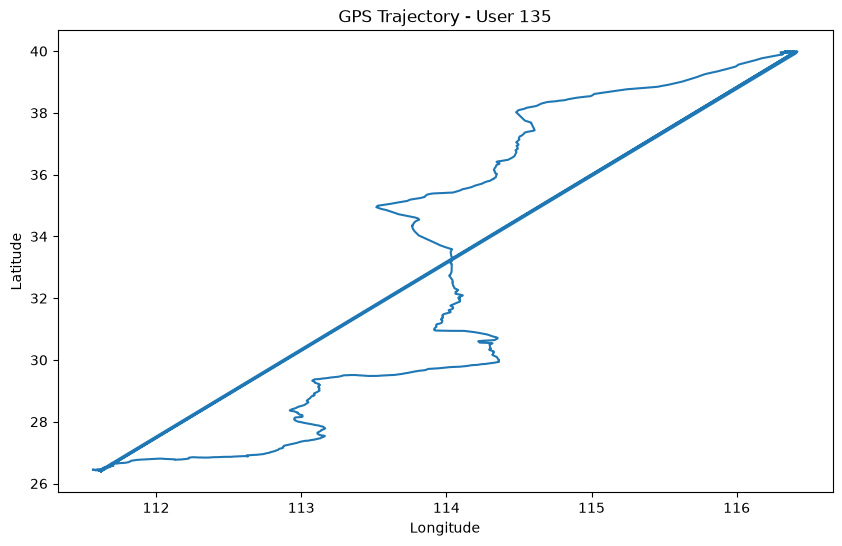

In [22]:
import matplotlib.pyplot as plt

sample_user = gps_data["user_id"].iloc[0]

user_data = gps_data[
    gps_data["user_id"] == sample_user
]

plt.figure(figsize=(10, 6))

plt.plot(
    user_data["longitude"],
    user_data["latitude"]
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"GPS Trajectory - User {sample_user}")

plt.show()

In [23]:
print("Latitude range:")
print(gps_data["latitude"].min(), gps_data["latitude"].max())

print("\nLongitude range:")
print(gps_data["longitude"].min(), gps_data["longitude"].max())

Latitude range:
1.044024 400.166666666667

Longitude range:
-179.9695933 179.9969416
